In [26]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import os

# --------------------------------------------------
# Load station CSV (already created by you)
# --------------------------------------------------
df = pd.read_csv("./output/csv/all_csv_files/each_file_skew_classification.csv")

# convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(df.Lon, df.Lat)]
gdf_stations = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# --------------------------------------------------
# Load tectonic unit shapefiles
# --------------------------------------------------
TECTONIC_DIR = "../data/mccourt_2013_tectonic_units"

unit_files = {
    "archean": "archaean.shp",
    "paleoproterozoic_shields": "paleoproterozoic_shields.shp",
    "paleoproterozoic_belts": "paleoproterozoic_belts.shp",
    "mesoproterozoic_belts": "mesoproterozoic_belts.shp",
    "neoproterozoic": "neoproterozoic.shp",
    "limpopo": "limpopo.shp"
}

# initialize column
gdf_stations["Tectonic_Unit"] = "unknown"

# --------------------------------------------------
# Spatial join manually (unit by unit)
# --------------------------------------------------
for unit, shp in unit_files.items():
    path = os.path.join(TECTONIC_DIR, shp)
    if not os.path.exists(path):
        print(f"Missing {path}")
        continue

    gdf_unit = gpd.read_file(path)

    # ensure same CRS
    if gdf_unit.crs != gdf_stations.crs:
        gdf_unit = gdf_unit.to_crs(gdf_stations.crs)

    # spatial join
    joined = gpd.sjoin(
        gdf_stations,
        gdf_unit,
        how="left",
        predicate="within"
    )

    # assign tectonic unit where matched
    mask = joined.index_right.notna()
    gdf_stations.loc[mask, "Tectonic_Unit"] = unit

# --------------------------------------------------
# Save final table
# --------------------------------------------------
out = "./output/csv/all_csv_files/each_file_skew_classification_with_units.csv"
gdf_stations.drop(columns="geometry").to_csv(out, index=False)

print("Saved", out)
print(gdf_stations["Tectonic_Unit"].value_counts())


Saved ./output/csv/all_csv_files/each_file_skew_classification_with_units.csv
Tectonic_Unit
archean                     269
paleoproterozoic_shields    165
neoproterozoic              155
mesoproterozoic_belts        73
limpopo                      69
paleoproterozoic_belts       53
Name: count, dtype: int64


In [28]:
import os, re, numpy as np, pandas as pd
from mt_metadata.transfer_functions import TF

mu0 = 4*np.pi*1e-7

# -------------------------------
# Load 1D sites
# -------------------------------
skew_df = pd.read_csv("./output/csv/all_csv_files/each_file_skew_classification_with_units.csv")

good_sites = set(skew_df.loc[skew_df.Is1D, "Site"])

print("Total 1D sites:", len(good_sites))

# -------------------------------
# Clean output directory FIRST
# -------------------------------
outdir = "./output/csv/all_csv_files/determinant_per_station"
os.makedirs(outdir, exist_ok=True)

for f in os.listdir(outdir):
    if f.endswith(".csv"):
        os.remove(os.path.join(outdir, f))

print("Old determinant files removed")

# -------------------------------
# Helpers
# -------------------------------
def sanitize(path):
    with open(path,"r",errors="ignore") as f:
        lines = f.readlines()
    out=[]
    for l in lines:
        if l.strip().startswith(">!"):
            out.append(l); continue
        l=re.sub(r"\*+"," -9999 ",l)
        l=re.sub(r"(?<![0-9eE+\-])0\.0(?![0-9eE+\-])"," -9999 ",l)
        out.append(l)
    return "".join(out)

def read_tf(path):
    with open("./output/temp_files/_tmp.edi","w") as f:
        f.write(sanitize(path))
    tf = TF()
    tf.read("./output/temp_files/_tmp.edi")
    return tf

# -------------------------------
# Compute determinant ONLY for 1D
# -------------------------------
edi_folder = "../data/all_station_EDI_data"
count = 0

for f in sorted(os.listdir(edi_folder)):
    if not f.lower().endswith(".edi"):
        continue

    site = f.replace(".edi","")
    if site not in good_sites:
        continue

    tf = read_tf(os.path.join(edi_folder, f))
    Z = np.array(tf.impedance.data, complex)
    periods = np.array(tf.period.data, float)

    Zdet = np.sqrt(Z[:,0,1]*Z[:,1,0] - Z[:,0,0]*Z[:,1,1])
    omega = 2*np.pi/periods
    rho = (np.abs(Zdet)**2 / (mu0 * omega)) * 1e-6
    phase = np.angle(Zdet, deg=True)

    pd.DataFrame({
        "period_s": periods,
        "rho_det": rho,
        "phase_det_deg": phase
    }).to_csv(f"{outdir}/{site}_det.csv", index=False)

    count += 1

print("Determinant computed for", count, "1D sites only")


Total 1D sites: 293
Old determinant files removed
Determinant computed for 293 1D sites only


In [29]:
import glob, pandas as pd

files = glob.glob("./output/csv/all_csv_files/determinant_per_station/*_det.csv")
print("Determinant files:", len(files))

skew_df = pd.read_csv("./output/csv/all_csv_files/each_file_skew_classification.csv")
print("1D sites:", (skew_df.Is1D==True).sum())


Determinant files: 293
1D sites: 293


Saved QC grid to ./output/images/all images/qc_grid.png
Wrote determinant_station_summary_with_slope.csv


/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_95700/2966553723.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_95700/2966553723.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_95700/2966553723.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_95700/2966553723.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_95700/2966553723.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/i

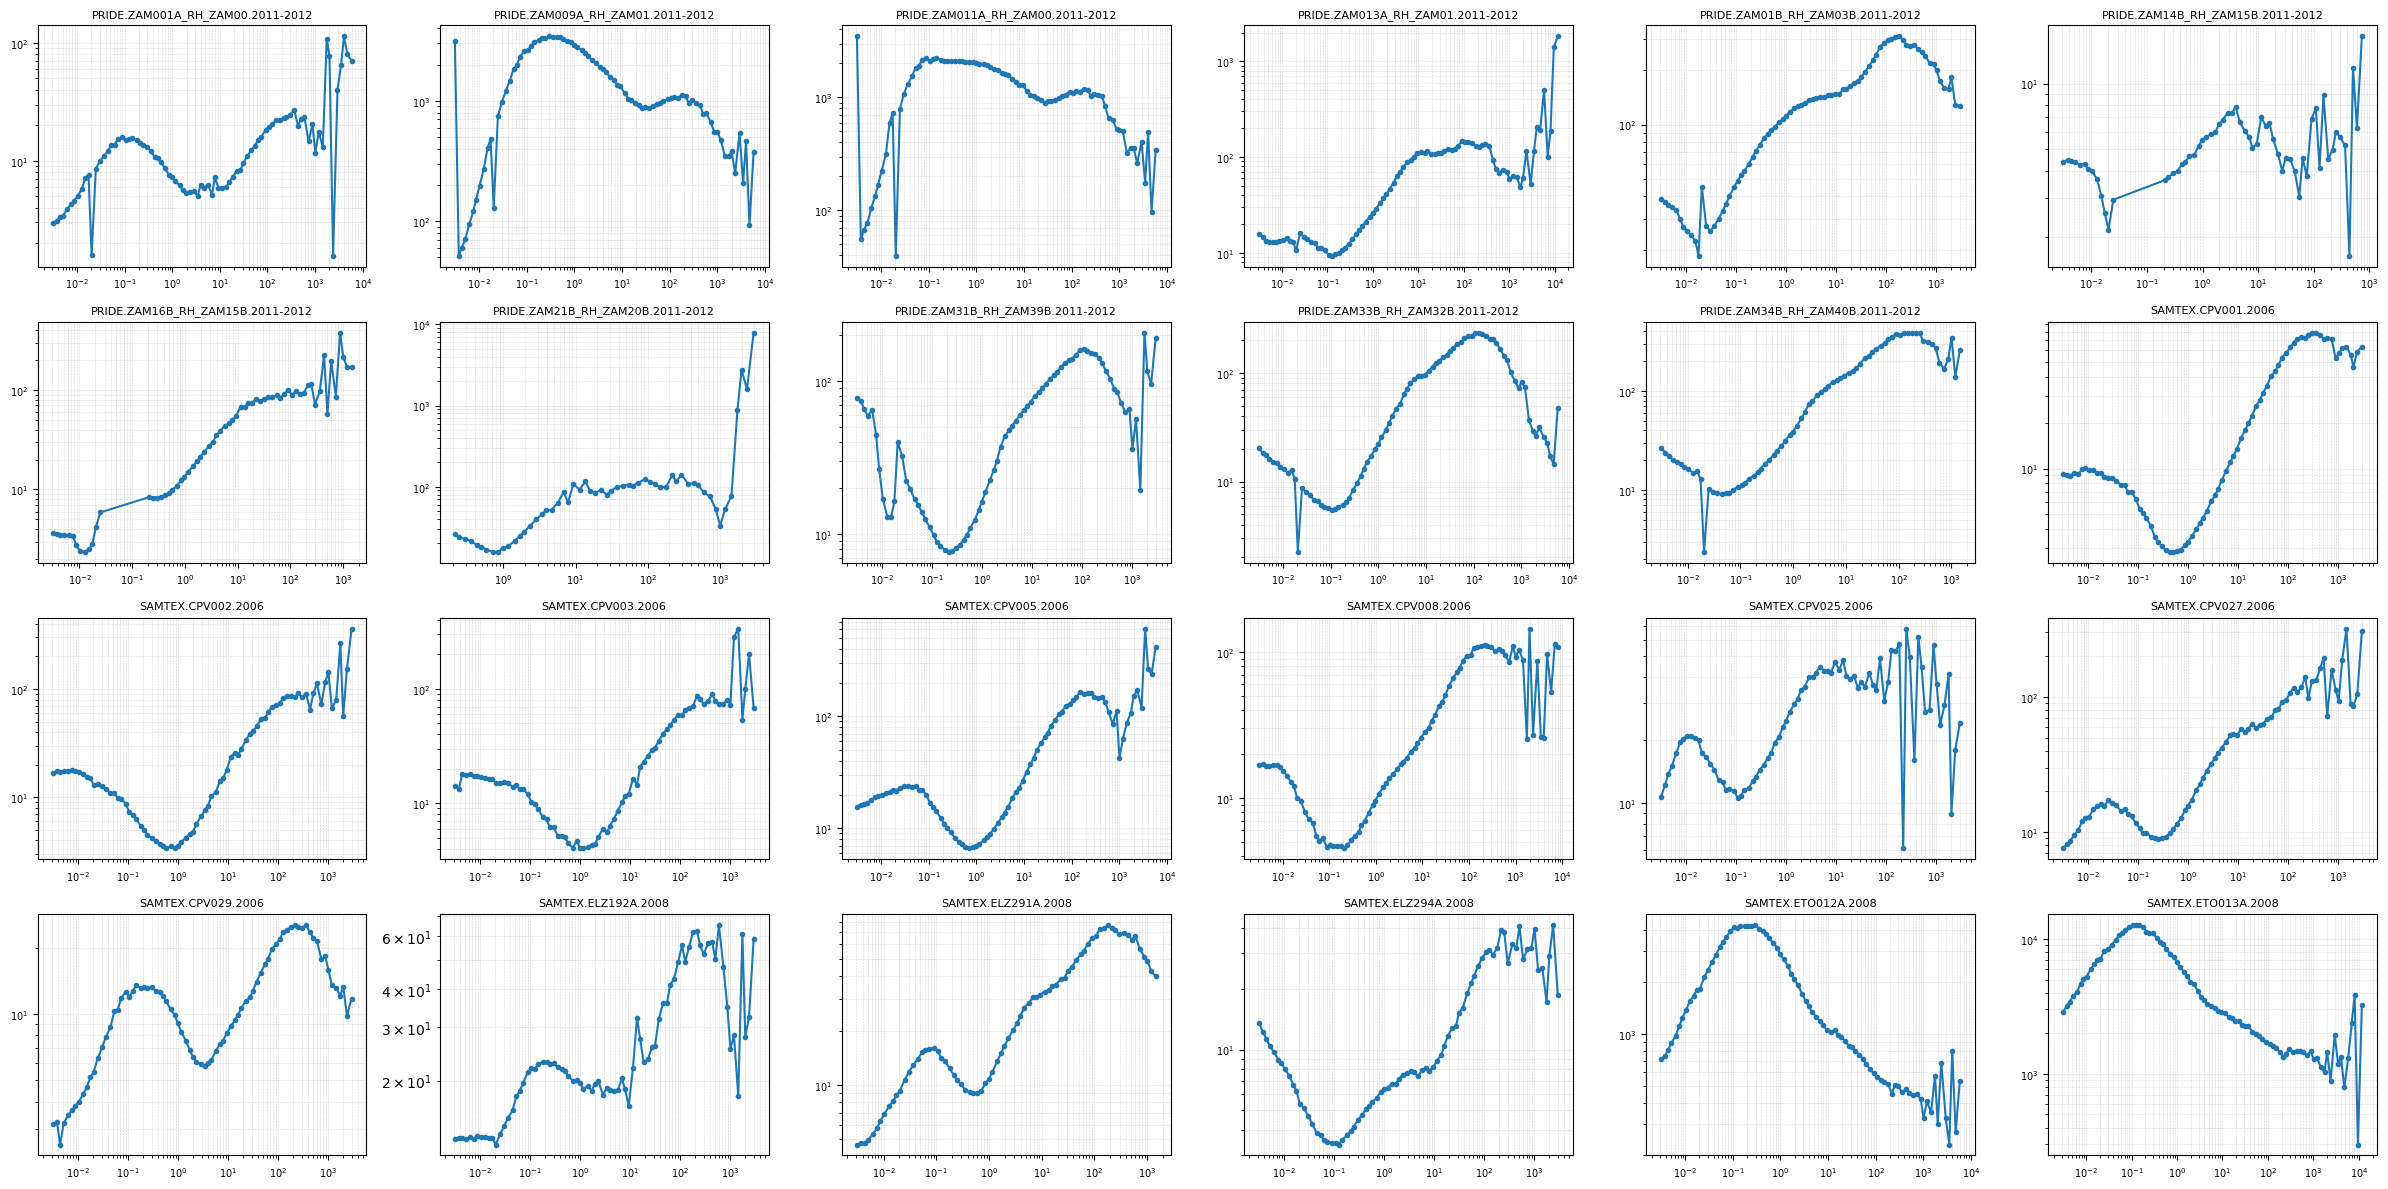

In [31]:
# 04_qc_plot_and_compute_slope.py
import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt

PER_STATION_DIR = "./output/csv/all_csv_files/determinant_per_station"
station_csvs = sorted(glob.glob(os.path.join(PER_STATION_DIR,"*_det.csv")))

# quick grid plot
def plot_grid(csv_files, ncols=6, max_plots=24, save_png="./output/images/all images/qc_grid.png"):
    n = min(len(csv_files), max_plots)
    nrows = int(np.ceil(n/ncols))
    fig = plt.figure(figsize=(4*ncols,3*nrows))
    for i,f in enumerate(csv_files[:n]):
        df = pd.read_csv(f)
        periods = df['period_s']; rho = df['rho_det']
        ax = fig.add_subplot(nrows,ncols,i+1)
        ax.loglog(periods, rho, marker='o', markersize=3, linestyle='-')
        ax.set_title(os.path.basename(f).replace("_det.csv",""), fontsize=8)
        ax.grid(True, which='both', lw=0.4, ls='--', alpha=0.5)
        ax.tick_params(axis='both', labelsize=7)
    plt.tight_layout(); fig.savefig(save_png, dpi=200)
    print("Saved QC grid to", save_png)

def compute_slope_midband(periods, rho, pmin=1, pmax=100):
    mask = (periods>=pmin) & (periods<=pmax) & np.isfinite(rho)
    if mask.sum() < 4: return np.nan
    x = np.log10(periods[mask]); y = np.log10(rho[mask])
    return float(np.polyfit(x,y,1)[0])

plot_grid(station_csvs, ncols=6, max_plots=24)

# compute slopes and add to summary
summary = pd.read_csv("./output/csv/all_csv_files/determinant_station_summary_for_QGIS.csv")
slopes = []
for f in station_csvs:
    site = os.path.basename(f).replace("_det.csv","").replace("_"," ").strip()
    df = pd.read_csv(f)
    s = compute_slope_midband(df['period_s'].values, df['rho_det'].values)
    slopes.append((site,s))
sdf = pd.DataFrame(slopes, columns=["Site","Slope_mid_1_100s"])
outdf = summary.merge(sdf, on="Site", how="left")
outdf.to_csv("./output/csv/all_csv_files/determinant_station_summary_with_slope.csv", index=False)
print("Wrote determinant_station_summary_with_slope.csv")


In [33]:
# qc_plots_by_tectonic_unit.py
# Final, clean, and safe version

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# INPUT PATHS
# ----------------------------------
INFO_CSV = "./output/csv/all_csv_files/each_file_skew_classification_with_units.csv"
DET_DIR = "./output/csv/all_csv_files/determinant_per_station"
OUT_DIR = "./output/images/all images/qc_plots_by_unit"

os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------
# LOAD METADATA
# ----------------------------------
info = pd.read_csv(INFO_CSV)

# clean strings (VERY IMPORTANT)
info["Site"] = info["Site"].astype(str).str.strip()
info["Tectonic_Unit"] = info["Tectonic_Unit"].astype(str).str.strip()

# keep only 1D stations
info = info[info["Is1D"] == True]

print("Total 1D stations:", len(info))

# ----------------------------------
# LOOP OVER TECTONIC UNITS
# ----------------------------------
for unit in sorted(info["Tectonic_Unit"].unique()):

    unit_df = info[info["Tectonic_Unit"] == unit]

    files = []
    missing = []

    for site in unit_df["Site"]:
        f = os.path.join(DET_DIR, f"{site}_det.csv")
        if os.path.exists(f):
            files.append(f)
        else:
            missing.append(site)

    # skip if no determinant files found
    if not files:
        print(f"[SKIPPED] {unit} → no determinant files")
        continue

    print(f"[PLOTTING] {unit} | files = {len(files)} | missing = {len(missing)}")

    # ----------------------------------
    # FIGURE LAYOUT
    # ----------------------------------
    ncols = 6
    nrows = int(np.ceil(len(files) / ncols))

    fig = plt.figure(figsize=(4 * ncols, 3 * nrows))

    # ----------------------------------
    # PLOT EACH STATION
    # ----------------------------------
    for i, f in enumerate(files):
        df = pd.read_csv(f)

        # safety check
        if "period_s" not in df.columns or "rho_det" not in df.columns:
            print(f"[BAD FILE] {f} → missing columns")
            continue

        ax = fig.add_subplot(nrows, ncols, i + 1)

        ax.loglog(
            df["period_s"],
            df["rho_det"],
            "o-",
            markersize=2,
            linewidth=0.8
        )

        ax.set_title(
            os.path.basename(f).replace("_det.csv", ""),
            fontsize=7
        )

        ax.grid(True, which="both", alpha=0.4)
        ax.tick_params(labelsize=6)

    # ----------------------------------
    # TITLES & SAVE
    # ----------------------------------
    plt.suptitle(
        f"Tectonic Unit: {unit}  (n = {len(files)})",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # make filename safe
    safe_unit = unit.replace(" ", "_").replace("/", "_")
    out = os.path.join(OUT_DIR, f"qc_{safe_unit}.png")

    plt.savefig(out, dpi=200)
    plt.close()

    print("Saved →", out)

print("DONE")


Total 1D stations: 293
[PLOTTING] archean | files = 82 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_archean.png
[PLOTTING] limpopo | files = 45 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_limpopo.png
[PLOTTING] mesoproterozoic_belts | files = 33 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_mesoproterozoic_belts.png
[PLOTTING] neoproterozoic | files = 24 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_neoproterozoic.png
[PLOTTING] paleoproterozoic_belts | files = 31 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_paleoproterozoic_belts.png
[PLOTTING] paleoproterozoic_shields | files = 78 | missing = 0
Saved → ./output/images/all images/qc_plots_by_unit/qc_paleoproterozoic_shields.png
DONE


In [34]:
import pandas as pd

# ---------------------------
# Your selected 24 stations
# ---------------------------
stations = [
   # Archean
    "SAMTEX.bot228.2005",
    "SAMTEX.rtz401.2005",
    "SAMTEX.kap067.2003",
    "SAMTEX.bot407.2005",

    # Limpopo
    "SAMTEX.bot416.2005",
    "SAMTEX.kal017.2008",
    "SAMTEX.san006.2008",
    "SAMTEX.san008.2008",

    # Mesoproterozoic belts
    "SAMTEX.kap010.2003",
    "SAMTEX.zim128.2005",
    "SAMTEX.mof102.2005",
    "SAMTEX.NEN003.2006",

    # Neoproterozoic
    "SAMTEX.ELZ291A.2008",
    "SAMTEX.dmb017.2006",
    "SAMTEX.oka008.2006",
    "SAMTEX.CPV027.2006",

    # Paleoproterozoic belts
    "SAMTEX.k2g006.2006",
    "SAMTEX.mof107.2005",
    "SAMTEX.san011.2008",
    "SAMTEX.mak002.2006",

    # Paleoproterozoic shields
    "SAMTEX.kim422.2004",
    "SAMTEX.kim432.2004",
    "SAMTEX.kim435.2004",
    "SAMTEX.rtz417.2005"
]

# ---------------------------
# Load CSV
# ---------------------------
df = pd.read_csv("./output/csv/all_csv_files/each_file_skew_classification_with_units.csv")

available_sites = set(df["Site"].astype(str))

# ---------------------------
# Check presence
# ---------------------------
present = []
missing = []

for s in stations:
    if s in available_sites:
        present.append(s)
    else:
        missing.append(s)

# ---------------------------
# Print results
# ---------------------------
print(f"Total selected stations: {len(stations)}")
print(f"Present in CSV: {len(present)}")
print(f"Missing from CSV: {len(missing)}")

print("\nPresent stations:")
for s in present:
    print(" ", s)

print("\nMissing stations:")
for s in missing:
    print(" ", s)


Total selected stations: 24
Present in CSV: 24
Missing from CSV: 0

Present stations:
  SAMTEX.bot228.2005
  SAMTEX.rtz401.2005
  SAMTEX.kap067.2003
  SAMTEX.bot407.2005
  SAMTEX.bot416.2005
  SAMTEX.kal017.2008
  SAMTEX.san006.2008
  SAMTEX.san008.2008
  SAMTEX.kap010.2003
  SAMTEX.zim128.2005
  SAMTEX.mof102.2005
  SAMTEX.NEN003.2006
  SAMTEX.ELZ291A.2008
  SAMTEX.dmb017.2006
  SAMTEX.oka008.2006
  SAMTEX.CPV027.2006
  SAMTEX.k2g006.2006
  SAMTEX.mof107.2005
  SAMTEX.san011.2008
  SAMTEX.mak002.2006
  SAMTEX.kim422.2004
  SAMTEX.kim432.2004
  SAMTEX.kim435.2004
  SAMTEX.rtz417.2005

Missing stations:


In [37]:
import pandas as pd

# ---------------------------
# Selected 24 stations
# ---------------------------
stations = [
    # Archean
    "SAMTEX.bot228.2005",
    "SAMTEX.rtz401.2005",
    "SAMTEX.kap067.2003",
    "SAMTEX.bot407.2005",

    # Limpopo
    "SAMTEX.bot416.2005",
    "SAMTEX.kal017.2008",
    "SAMTEX.san006.2008",
    "SAMTEX.san008.2008",

    # Mesoproterozoic belts
    "SAMTEX.kap010.2003",
    "SAMTEX.zim128.2005",
    "SAMTEX.mof102.2005",
    "SAMTEX.NEN003.2006",

    # Neoproterozoic
    "SAMTEX.ELZ291A.2008",
    "SAMTEX.dmb017.2006",
    "SAMTEX.oka008.2006",
    "SAMTEX.CPV027.2006",

    # Paleoproterozoic belts
    "SAMTEX.k2g006.2006",
    "SAMTEX.mof107.2005",
    "SAMTEX.san011.2008",
    "SAMTEX.mak002.2006",

    # Paleoproterozoic shields
    "SAMTEX.kim422.2004",
    "SAMTEX.kim432.2004",
    "SAMTEX.kim435.2004",
    "SAMTEX.rtz417.2005"
]



# ---------------------------
# Load master table
# ---------------------------
df = pd.read_csv("./output/csv/all_csv_files/each_file_skew_classification_with_units.csv")

# filter only selected stations
selected_df = df[df["Site"].isin(stations)].copy()

# safety check
assert len(selected_df) == 24, f"Expected 24 stations, got {len(selected_df)}"

# save
selected_df.to_csv("./output/csv/all_csv_files/selected_24_stations.csv", index=False)

print("Saved selected_24_stations.csv")
print(selected_df[["Site", "Tectonic_Unit", "Lat", "Lon"]])


Saved selected_24_stations.csv
                    Site             Tectonic_Unit        Lat        Lon
2     SAMTEX.bot407.2005                   archean -24.345728  25.525831
8     SAMTEX.mof107.2005    paleoproterozoic_belts -20.456006  24.490556
9     SAMTEX.kim432.2004  paleoproterozoic_shields -23.916311  18.546750
13    SAMTEX.san008.2008                   limpopo -22.128394  24.176858
14    SAMTEX.san006.2008                   limpopo -22.489006  24.169469
52    SAMTEX.bot228.2005                   archean -24.139922  23.144806
53    SAMTEX.rtz401.2005                   archean -24.236006  23.245000
73    SAMTEX.san011.2008    paleoproterozoic_belts -21.653200  24.065831
77    SAMTEX.kim422.2004  paleoproterozoic_shields -25.106867  19.952028
78    SAMTEX.rtz417.2005  paleoproterozoic_shields -23.630478  20.926194
90    SAMTEX.kal017.2008                   limpopo -22.644700  24.756389
125   SAMTEX.kim435.2004  paleoproterozoic_shields -23.593811  18.124806
127   SAMTEX.k2g006.

Loaded tectonic unit: afr_g2014_2013_0
Loaded tectonic unit: paleoproterozoic_belts
Loaded tectonic unit: paleoproterozoic_shields
Loaded tectonic unit: mesoproterozoic_belts
Loaded tectonic unit: neoproterozoic
Loaded tectonic unit: archaean
Loaded tectonic unit: limpopo


/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/c

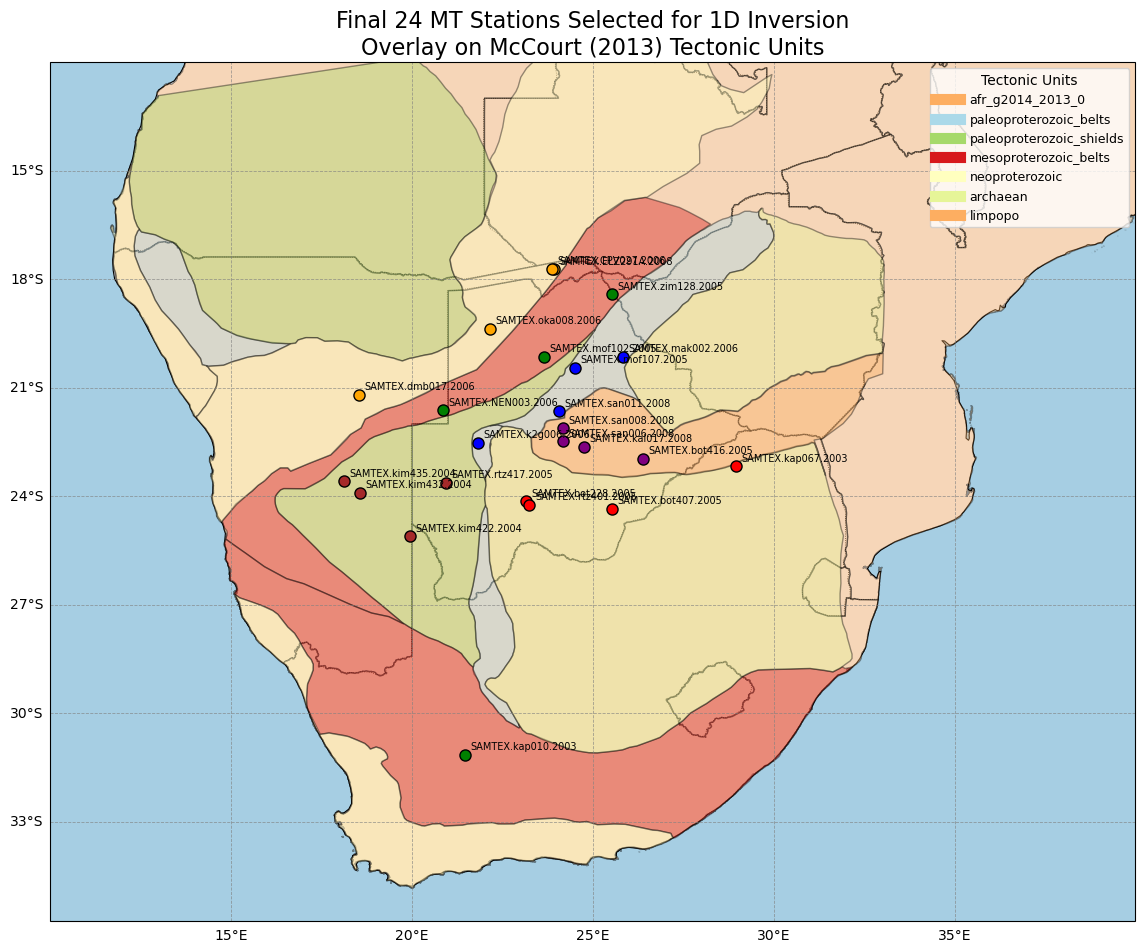

Saved final_24_stations_geology_map.png


In [39]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature

# ----------------------------------------------------
# INPUT FILES
# ----------------------------------------------------
STATION_CSV = "./output/csv/all_csv_files/selected_24_stations.csv"
TECTONIC_DIR = "../data/mccourt_2013_tectonic_units"

# ----------------------------------------------------
# MAP EXTENT (Southern Africa)
# ----------------------------------------------------
ZOOM_EXTENT = [10, 40, -35, -12]   # [lon_min, lon_max, lat_min, lat_max]

# ----------------------------------------------------
# LOAD SELECTED 24 STATIONS
# ----------------------------------------------------
stations = pd.read_csv(STATION_CSV)

# ----------------------------------------------------
# LOAD ALL TECTONIC SHAPEFILES AUTOMATICALLY
# ----------------------------------------------------
def load_all_shapefiles(directory, clip_extent):
    layers = {}

    for file in os.listdir(directory):
        if file.lower().endswith(".shp"):
            name = file.replace(".shp", "")
            path = os.path.join(directory, file)

            gdf = gpd.read_file(path)

            # ensure WGS84
            if gdf.crs and gdf.crs.to_string() != "EPSG:4326":
                gdf = gdf.to_crs("EPSG:4326")

            clipped = gdf.cx[
                clip_extent[0]:clip_extent[1],
                clip_extent[2]:clip_extent[3]
            ]

            if len(clipped) > 0:
                layers[name] = clipped
                print(f"Loaded tectonic unit: {name}")

    return layers

tectonic_layers = load_all_shapefiles(TECTONIC_DIR, ZOOM_EXTENT)

# ----------------------------------------------------
# PLOT MAP
# ----------------------------------------------------
plt.figure(figsize=(14, 14))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(ZOOM_EXTENT)

# Base map
ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
ax.add_feature(cfeature.OCEAN, facecolor="#a6cee3")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# ----------------------------------------------------
# PLOT TECTONIC UNITS
# ----------------------------------------------------
unit_colors = [
    "#fdae61", "#abd9e9", "#a6d96a",
    "#d7191c", "#ffffbf", "#e6f598"
]

for i, (name, gdf) in enumerate(tectonic_layers.items()):
    color = unit_colors[i % len(unit_colors)]

    feat = ShapelyFeature(
        gdf.geometry,
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor="black",
        alpha=0.4
    )

    ax.add_feature(feat)
    ax.plot([], [], color=color, linewidth=8, label=name)

# ----------------------------------------------------
# PLOT SELECTED 24 STATIONS
# ----------------------------------------------------
unit_marker_colors = {
    "archean": "red",
    "limpopo": "purple",
    "mesoproterozoic_belts": "green",
    "neoproterozoic": "orange",
    "paleoproterozoic_belts": "blue",
    "paleoproterozoic_shields": "brown"
}

for _, row in stations.iterrows():
    color = unit_marker_colors.get(row["Tectonic_Unit"], "black")

    ax.plot(
        row["Lon"], row["Lat"],
        marker="o",
        markersize=8,
        markeredgecolor="black",
        color=color,
        transform=ccrs.PlateCarree(),
        zorder=30
    )

    # station label
    ax.text(
        row["Lon"] + 0.15,
        row["Lat"] + 0.15,
        row["Site"],
        fontsize=7,
        transform=ccrs.PlateCarree(),
        zorder=31
    )

# ----------------------------------------------------
# GRIDLINES
# ----------------------------------------------------
gl = ax.gridlines(draw_labels=True, linewidth=0.6,
                  linestyle="--", color="gray", alpha=0.7)
gl.top_labels = False
gl.right_labels = False

# ----------------------------------------------------
# TITLE + LEGEND
# ----------------------------------------------------
plt.title(
    "Final 24 MT Stations Selected for 1D Inversion\n"
    "Overlay on McCourt (2013) Tectonic Units",
    fontsize=16
)

plt.legend(
    loc="upper right",
    title="Tectonic Units",
    fontsize=9,
    title_fontsize=10
)

# ----------------------------------------------------
# SAVE & SHOW
# ----------------------------------------------------
plt.savefig("./output/images/all images/final_24_stations_geology_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved final_24_stations_geology_map.png")


Total selected stations: 24


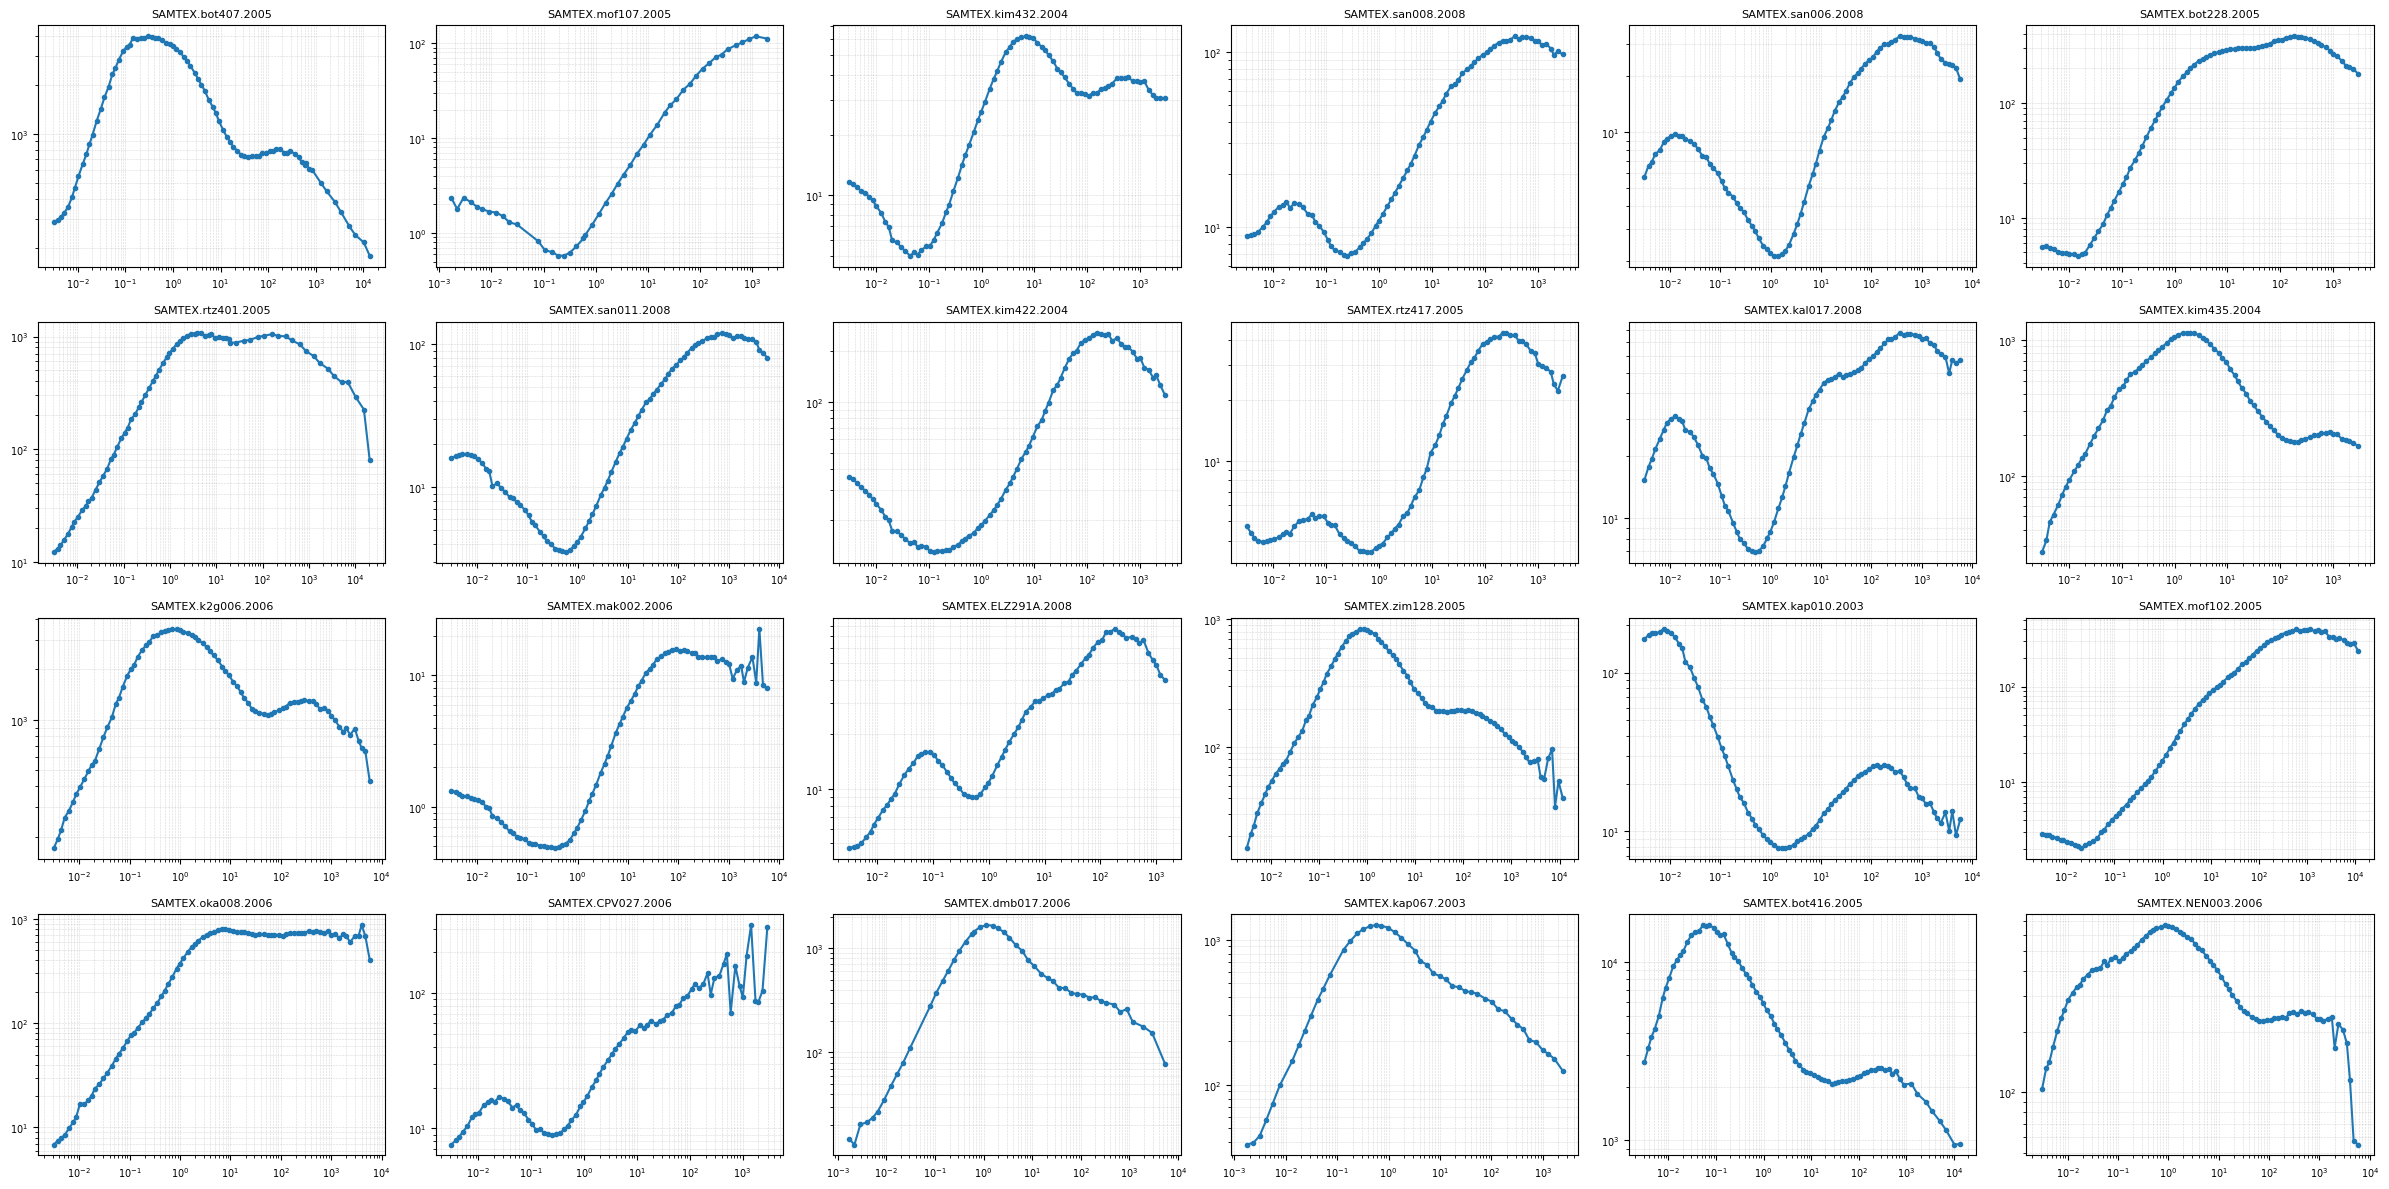

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# INPUTS
# ----------------------------------------------------
PER_STATION_DIR = "./output/csv/all_csv_files/determinant_per_station"
SELECTED_CSV = "./output/csv/all_csv_files/selected_24_stations.csv"
OUT_PNG = "./output/images/all images/qc_grid_selected_24.png"

# ----------------------------------------------------
# LOAD SELECTED 24 STATIONS
# ----------------------------------------------------
sel = pd.read_csv(SELECTED_CSV)

# build list of determinant csv files (ordered as in CSV)
station_csvs = []
for site in sel["Site"]:
    f = os.path.join(PER_STATION_DIR, f"{site}_det.csv")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing determinant file: {f}")
    station_csvs.append(f)

print("Total selected stations:", len(station_csvs))

# ----------------------------------------------------
# QC GRID PLOT FUNCTION
# ----------------------------------------------------
def plot_grid(csv_files, ncols=6, save_png="qc_grid.png"):
    n = len(csv_files)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, f in enumerate(csv_files):
        df = pd.read_csv(f)

        periods = df["period_s"].values
        rho = df["rho_det"].values

        ax = fig.add_subplot(nrows, ncols, i + 1)
        ax.loglog(periods, rho, "o-", markersize=3)

        ax.set_title(
            os.path.basename(f).replace("_det.csv", ""),
            fontsize=8
        )

        ax.grid(True, which="both", lw=0.4, ls="--", alpha=0.5)
        ax.tick_params(axis="both", labelsize=7)

    plt.tight_layout()
    plt.savefig(save_png, dpi=300)
    plt.show()   # 🔥 this displays the figure


# ----------------------------------------------------
# PLOT
# ----------------------------------------------------
plot_grid(station_csvs, ncols=6, save_png=OUT_PNG)


In [42]:
import pandas as pd
import numpy as np
from mt_metadata.transfer_functions import TF

# -------------------------------
# INPUT
# -------------------------------
edi_file = "../data/all_station_EDI_data/SAMTEX.kim422.2004.edi"
output_csv = "./output/csv/all_csv_files/SAMTEX.kim422.2004_Zxy.csv"

# -------------------------------
# READ EDI
# -------------------------------
tf = TF(fn=edi_file)
tf.read()

# -------------------------------
# EXTRACT DATA DIRECTLY (THE FIX)
# -------------------------------
# Instead of converting to a dataset, access attributes directly from the tf object.
# These attributes are typically xarray DataArrays, so we use .values to get numpy arrays.

periods = tf.period

# Extract Impedance (Z) and Error
# Note: tf.impedance returns the complex impedance tensor
Z = tf.impedance.values          # shape (n_periods, 2, 2)
Z_err = tf.impedance_error.values # shape (n_periods, 2, 2)

# -------------------------------
# SELECT Zxy
# -------------------------------
# Indices: [period_index, output_channel, input_channel]
# 0=x, 1=y. So [:, 0, 1] is Zxy (Output X, Input Y)
Zxy = Z[:, 0, 1]
Zxy_err = Z_err[:, 0, 1]

# -------------------------------
# BUILD DATAFRAME
# -------------------------------
df = pd.DataFrame({
    "period_s": periods,
    "Z_real": np.real(Zxy),
    "Z_imag": np.imag(Zxy),
    "Z_err": Zxy_err
})

# -------------------------------
# CLEAN
# -------------------------------
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.sort_values("period_s", inplace=True)

# -------------------------------
# SAVE
# -------------------------------
df.to_csv(output_csv, index=False)

print("CSV created:", output_csv)

CSV created: ./output/csv/all_csv_files/SAMTEX.kim422.2004_Zxy.csv


In [1]:
import pandas as pd
import numpy as np
from mt_metadata.transfer_functions import TF

# -------------------------------
# INPUT
# -------------------------------
edi_file = "../data/all_station_EDI_data/SAMTEX.kim422.2004.edi"
output_csv = "./output/csv/all_csv_files/SAMTEX.kim422.2004_Zxy.csv"

# -------------------------------
# READ EDI
# -------------------------------
tf = TF(fn=edi_file)
tf.read()

# -------------------------------
# EXTRACT DATA
# -------------------------------
periods = tf.period

Z = tf.impedance.values
Z_err = tf.impedance_error.values  # variance

# -------------------------------
# SELECT Zxy
# -------------------------------
Zxy = Z[:, 0, 1]

# TAKE SQRT → standard deviation
# Zxy_err = np.sqrt(Z_err[:, 0, 1])
Zxy_err = 0.15 * np.abs(Zxy)

# -------------------------------
# BUILD DATAFRAME
# -------------------------------
df = pd.DataFrame({
    "period_s": periods,
    "Z_real": np.real(Zxy),
    "Z_imag": np.imag(Zxy),
    "Z_err": Zxy_err
})

# -------------------------------
# CLEAN
# -------------------------------
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.sort_values("period_s", inplace=True)

# -------------------------------
# DOWNSAMPLE
# -------------------------------
target_points = 20
step = max(1, len(df) // target_points)
df = df.iloc[::step].reset_index(drop=True)

# -------------------------------
# SAVE
# -------------------------------
df.to_csv(output_csv, index=False)

print("CSV created:", output_csv)


CSV created: ./output/csv/all_csv_files/SAMTEX.kim422.2004_Zxy.csv


In [2]:
df.to_csv("./output/csv/all_csv_files/SAMTEX.kim422.2004_Zxy.dat",
          sep=" ",
          header=False,
          index=False)


In [12]:
import numpy as np
from mt_metadata.transfer_functions import TF

# -------------------------------
# INPUT
# -------------------------------
edi_file = "../data/all_station_EDI_data/SAMTEX.kim422.2004.edi"
output_dat = "./test1.dat"
target_points = 20
noise_percent = 3.0   # same as MATLAB MT.noise_prcnt

# -------------------------------
# READ EDI
# -------------------------------
tf = TF(fn=edi_file)
tf.read()

periods = tf.period
Z = tf.impedance.values   # EDI units: (mV/km)/nT

# -------------------------------
# SELECT Zxy ONLY
# -------------------------------
Zxy = Z[:, 0, 1]

# ✅ UNIT CONVERSION (DO NOT MOVE THIS)
# (mV/km)/nT → Ohms
Zxy = Zxy * 1e-3

# -------------------------------
# ERROR (MATCH MATLAB)
# -------------------------------
Zxy_err = 0.01 * noise_percent * np.abs(Zxy)

# -------------------------------
# CLEAN DATA
# -------------------------------
mask = (
    np.isfinite(periods) &
    np.isfinite(Zxy.real) &
    np.isfinite(Zxy.imag) &
    (np.abs(Zxy) > 0)
)

periods = periods[mask]
Zxy = Zxy[mask]
Zxy_err = Zxy_err[mask]

# -------------------------------
# SORT BY PERIOD
# -------------------------------
idx = np.argsort(periods)
periods = periods[idx]
Zxy = Zxy[idx]
Zxy_err = Zxy_err[idx]

# -------------------------------
# LOG-SPACE SUBSAMPLING
# -------------------------------
logP = np.log10(periods)
log_bins = np.linspace(logP.min(), logP.max(), target_points)

selected = np.unique([
    np.argmin(np.abs(logP - lb)) for lb in log_bins
])

periods = periods[selected]
Zxy = Zxy[selected]
Zxy_err = Zxy_err[selected]

# -------------------------------
# FINAL SORT
# -------------------------------
idx = np.argsort(periods)
periods = periods[idx]
Zxy = Zxy[idx]
Zxy_err = Zxy_err[idx]

# -------------------------------
# SAVE (EXACT MATLAB FORMAT)
# -------------------------------
with open(output_dat, "w") as f:
    for p, z, e in zip(periods, Zxy, Zxy_err):
        f.write(f"{p:12.5f} "
                f"{z.real:+10.4E} "
                f"{z.imag:+10.4E} "
                f"{e:+10.4E}\n")

print("✔ MT_data_Z.dat ready for inversion")
print("✔ Number of periods:", len(periods))


✔ MT_data_Z.dat ready for inversion
✔ Number of periods: 20


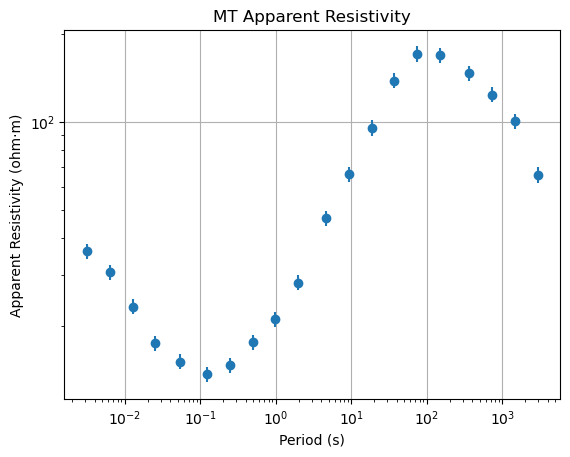

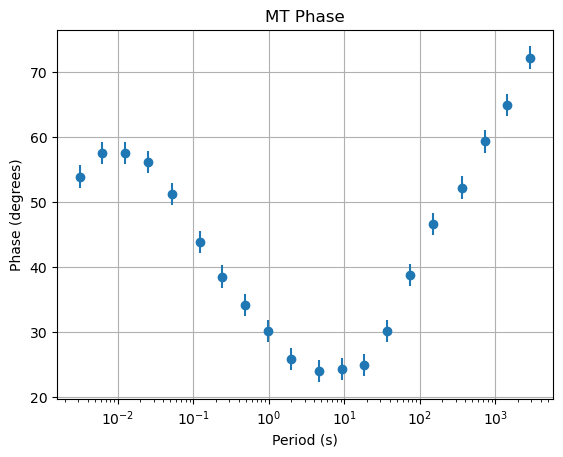

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load MT impedance data
# -------------------------------
# data = np.loadtxt("./MT_data_Z.dat")
data = np.loadtxt("./test1.dat")

period = data[:, 0]
Zr = data[:, 1]
Zi = data[:, 2]
Zerr = data[:, 3]

Z = Zr + 1j * Zi

# -------------------------------
# Physical constants
# -------------------------------
mu = 4 * np.pi * 1e-7
omega = 2 * np.pi / period

# -------------------------------
# Apparent resistivity & phase
# -------------------------------
absZ = np.abs(Z)

appres = (absZ ** 2) / (mu * omega)
phase = np.degrees(np.arctan2(Zi, Zr))

# -------------------------------
# Error estimation (same as MATLAB)
# -------------------------------
appres_err = 2 * absZ * (Zerr / (mu * omega))
phase_err = (Zerr / absZ) * (180 / np.pi)

# -------------------------------
# Plot apparent resistivity
# -------------------------------
plt.figure()
plt.errorbar(period, appres, yerr=appres_err, fmt='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Period (s)")
plt.ylabel("Apparent Resistivity (ohm·m)")
plt.title("MT Apparent Resistivity")
plt.grid(True)

# -------------------------------
# Plot phase
# -------------------------------
plt.figure()
plt.errorbar(period, phase, yerr=phase_err, fmt='o')
plt.xscale('log')
plt.xlabel("Period (s)")
plt.ylabel("Phase (degrees)")
plt.title("MT Phase")
plt.grid(True)

plt.show()
